# Segmentación de Clientes

In [1]:
#Librerías
#Análisis
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

#Preprocesamiento
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

#K-Means
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

#Clustering Jerárquico
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import AgglomerativeClustering

#DBSCAN
from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import DBSCAN

In [ ]:
#Cargando datos
data = pd.read_csv('/Datos sin procesar - Segmentación de Clientes.csv', sep='\t')
data.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


In [3]:
#Info general
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

## Análisis

### Columnas sin información útil

In [4]:
#Valores en las columnas Z_CostContact	y Z_Revenue
print(f'{data['Z_CostContact'].value_counts()}\n')
print(data['Z_Revenue'].value_counts())

Z_CostContact
3    2240
Name: count, dtype: int64

Z_Revenue
11    2240
Name: count, dtype: int64


In [5]:
#Eliminando columnas que no aportan información
data = data.drop(columns=['ID', 'Z_CostContact', 'Z_Revenue'])
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 26 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Year_Birth           2240 non-null   int64  
 1   Education            2240 non-null   object 
 2   Marital_Status       2240 non-null   object 
 3   Income               2216 non-null   float64
 4   Kidhome              2240 non-null   int64  
 5   Teenhome             2240 non-null   int64  
 6   Dt_Customer          2240 non-null   object 
 7   Recency              2240 non-null   int64  
 8   MntWines             2240 non-null   int64  
 9   MntFruits            2240 non-null   int64  
 10  MntMeatProducts      2240 non-null   int64  
 11  MntFishProducts      2240 non-null   int64  
 12  MntSweetProducts     2240 non-null   int64  
 13  MntGoldProds         2240 non-null   int64  
 14  NumDealsPurchases    2240 non-null   int64  
 15  NumWebPurchases      2240 non-null   i

### Año de nacimiento

In [6]:
#Resumen estadístico
data['Year_Birth'].describe().round(2)

count    2240.00
mean     1968.81
std        11.98
min      1893.00
25%      1959.00
50%      1970.00
75%      1977.00
max      1996.00
Name: Year_Birth, dtype: float64

Text(0, 0.5, 'Año de nacimiento')

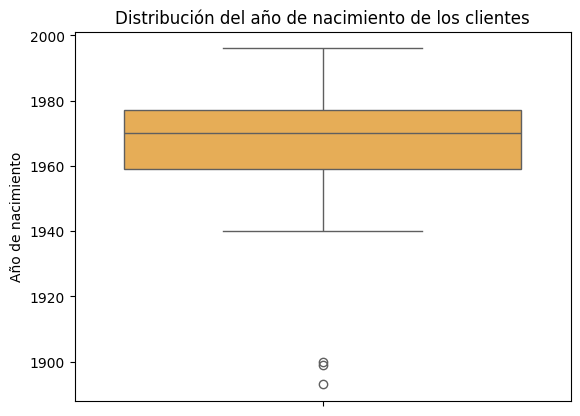

In [7]:
#Boxplot
sns.boxplot(
    data['Year_Birth'],
    color = sns.color_palette("YlOrBr")[2]
)

plt.title('Distribución del año de nacimiento de los clientes')
plt.ylabel('Año de nacimiento')

In [8]:
#Registros atípicos
data[data['Year_Birth'] < 1940]

,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,...,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Response
192,1900,2n Cycle,Divorced,36640.0,1,0,26-09-2013,99,15,6,...,1,2,5,0,0,0,0,0,1,0
239,1893,2n Cycle,Single,60182.0,0,1,17-05-2014,23,8,0,...,0,2,4,0,0,0,0,0,0,0
339,1899,PhD,Together,83532.0,0,0,26-09-2013,36,755,144,...,6,4,1,0,0,1,0,0,0,0


In [9]:
#Eliminando estos registros
data = data[data['Year_Birth'] >= 1920]
data[data['Year_Birth'] < 1940]

,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,...,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Response


In [10]:
#Creando columna Edad
data.loc[:, 'Age'] = 2026 - data['Year_Birth']
data.head()

,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,...,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Response,Age
0,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,88,...,4,7,0,0,0,0,0,0,1,69
1,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,1,...,2,5,0,0,0,0,0,0,0,72
2,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,49,...,10,4,0,0,0,0,0,0,0,61
3,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,4,...,4,6,0,0,0,0,0,0,0,42
4,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,43,...,6,5,0,0,0,0,0,0,0,45


In [11]:
#Resumen de edad
data['Age'].describe()

count    2237.000000
mean       57.098346
std        11.701917
min        30.000000
25%        49.000000
50%        56.000000
75%        67.000000
max        86.000000
Name: Age, dtype: float64

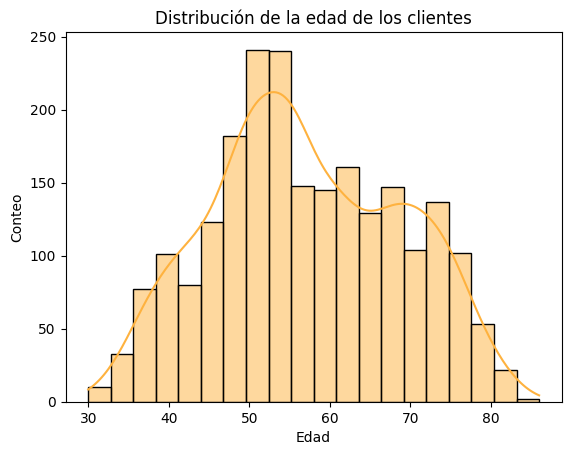

In [12]:
#Histograma de edades
sns.histplot(
    data['Age'],
    bins=20,
    kde=True,
    color = sns.color_palette("YlOrBr")[2]
)

plt.title('Distribución de la edad de los clientes')
plt.xlabel('Edad')
plt.ylabel('Conteo')
plt.show()

In [13]:
#Eliminando columna Year_Birth
data = data.drop(columns = ['Year_Birth'])
data.head()

,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,...,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Response,Age
0,Graduation,Single,58138.0,0,0,04-09-2012,58,635,88,546,...,4,7,0,0,0,0,0,0,1,69
1,Graduation,Single,46344.0,1,1,08-03-2014,38,11,1,6,...,2,5,0,0,0,0,0,0,0,72
2,Graduation,Together,71613.0,0,0,21-08-2013,26,426,49,127,...,10,4,0,0,0,0,0,0,0,61
3,Graduation,Together,26646.0,1,0,10-02-2014,26,11,4,20,...,4,6,0,0,0,0,0,0,0,42
4,PhD,Married,58293.0,1,0,19-01-2014,94,173,43,118,...,6,5,0,0,0,0,0,0,0,45


### Educación

In [14]:
#Valores de la variable educación
data['Education'].value_counts()

Education
Graduation    1127
PhD            485
Master         370
2n Cycle       201
Basic           54
Name: count, dtype: int64

In [15]:
#Traduciendo variables
data.loc[:, 'Education'] = data['Education'].replace({
    "Graduation": "Licenciatura",
    "PhD": "Doctorado",
    "Master": "Maestría",
    "2n Cycle": "Posgrado",
    "Basic": "Básica",
})

data['Education'].value_counts(ascending=False)

Education
Licenciatura    1127
Doctorado        485
Maestría         370
Posgrado         201
Básica            54
Name: count, dtype: int64

[Text(0, 1, '50.38%'),
 Text(0, 1, '21.68%'),
 Text(0, 1, '16.54%'),
 Text(0, 1, '8.99%'),
 Text(0, 1, '2.41%')]

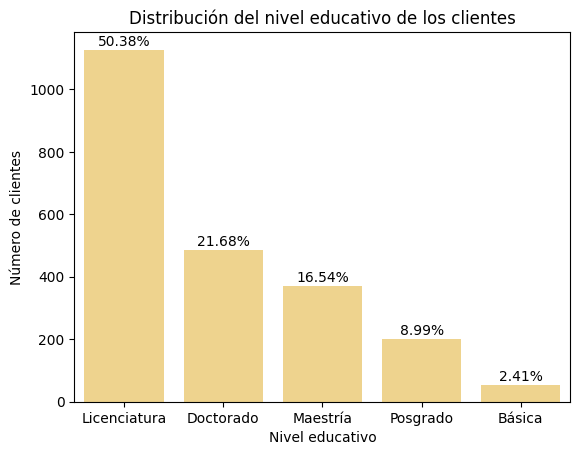

In [16]:
#Gráfico de barras
edu_bar = sns.countplot(
    data = data,
    x = 'Education',
    order = data['Education'].value_counts().index,
    color = sns.color_palette('YlOrBr')[1]
)

#Etiquetas
plt.title('Distribución del nivel educativo de los clientes')
plt.xlabel('Nivel educativo')
plt.ylabel('Número de clientes')

#Etiquetas de las barras con porcentajes
total = len(data) #Total de datos
heights = [p.get_height() for p in edu_bar.patches] #Altura de cada barra
labels = [f'{(h/total)*100:.2f}%' for h in heights] #Porcentajes
edu_bar.bar_label(edu_bar.containers[0], labels = labels, padding = 1)

### Estado Civil

In [17]:
#Estados civiles
data['Marital_Status'].value_counts()

Marital_Status
Married     864
Together    579
Single      479
Divorced    231
Widow        77
Alone         3
Absurd        2
YOLO          2
Name: count, dtype: int64

In [18]:
#Revisando datos incosistentes
data[data['Marital_Status'].isin(['Alone', 'Absurd', 'YOLO'])]

,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,...,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Response,Age
131,Maestría,Alone,61331.0,1,1,10-03-2013,42,534,5,47,...,6,8,0,0,0,0,0,0,0,68
138,Doctorado,Alone,35860.0,1,1,19-05-2014,37,15,0,8,...,2,5,1,0,0,0,0,0,1,53
153,Licenciatura,Alone,34176.0,1,0,12-05-2014,12,5,7,24,...,4,6,0,0,0,0,0,0,0,38
2093,Licenciatura,Absurd,79244.0,0,0,19-12-2012,58,471,102,125,...,7,1,0,0,1,1,0,0,1,33
2134,Maestría,Absurd,65487.0,0,0,10-01-2014,48,240,67,500,...,6,2,0,0,0,0,0,0,0,69
2177,Doctorado,YOLO,48432.0,0,1,18-10-2012,3,322,3,50,...,6,8,0,0,0,0,0,0,0,53
2202,Doctorado,YOLO,48432.0,0,1,18-10-2012,3,322,3,50,...,6,8,0,0,0,0,0,0,1,53


In [19]:
#Traduciendo y agregando "Alone" a "Single"
#Traduciendo variables
data.loc[:, 'Marital_Status'] = data['Marital_Status'].replace({
    "Married": "Casado",
    "Together": "Unión Libre",
    "Single": "Soltero",
    "Divorced": "Divorciado",
    "Widow": "Viudo",
    "Alone": "Soltero",
    "Absurd": "Soltero",
    "YOLO": "Soltero"
})

data['Marital_Status'].value_counts(ascending=False)

Marital_Status
Casado         864
Unión Libre    579
Soltero        486
Divorciado     231
Viudo           77
Name: count, dtype: int64

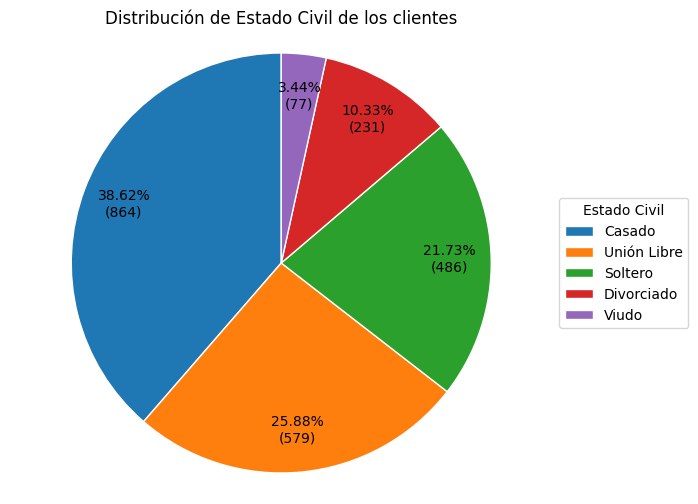

In [20]:
#Gráfico de Pastel
#Conteo
conteo = data['Marital_Status'].value_counts()
labels = conteo.index
sizes = conteo.values

# Función personalizada para mostrar el Porcentaje y la cantidad
def porcentajes(pct):
    total = sum(sizes)
    cantidad = int(round(pct * total / 100.0))
    return f'{pct:.2f}%\n({cantidad:d})'

#Gráfico
plt.figure(figsize=(7, 6))
plt.pie(
    sizes,
    autopct = porcentajes,
    startangle=90,
    pctdistance=0.8,
    labeldistance=1.1,
    wedgeprops={'edgecolor': 'white'}
)

#Leyenda
plt.legend(
    labels,
    title = 'Estado Civil',
    loc = 'center left',
    bbox_to_anchor=(1, 0, 0.5, 1)
)

#Título
plt.title('Distribución de Estado Civil de los clientes')
plt.axis('equal')
plt.show()

### Ingresos

In [21]:
#Resumen Estadístico
data['Income'].describe()

count      2213.000000
mean      52236.581563
std       25178.603047
min        1730.000000
25%       35246.000000
50%       51373.000000
75%       68487.000000
max      666666.000000
Name: Income, dtype: float64

In [22]:
#Valores faltantes
print(f'Cantidad de datos faltantes en la columna Ingresos: {data['Income'].isnull().sum()}')
print(f'Porcentaje: {(data['Income'].isnull().mean() * 100).round(2)}%')

Cantidad de datos faltantes en la columna Ingresos: 24
Porcentaje: 1.07%


([<matplotlib.axis.YTick at 0x186d6698a50>,
 [Text(0, 0, '0'),
  Text(0, 100000, '100000'),
  Text(0, 200000, '200000'),
  Text(0, 300000, '300000'),
  Text(0, 400000, '400000'),
  Text(0, 500000, '500000'),
  Text(0, 600000, '600000'),
  Text(0, 700000, '700000')])

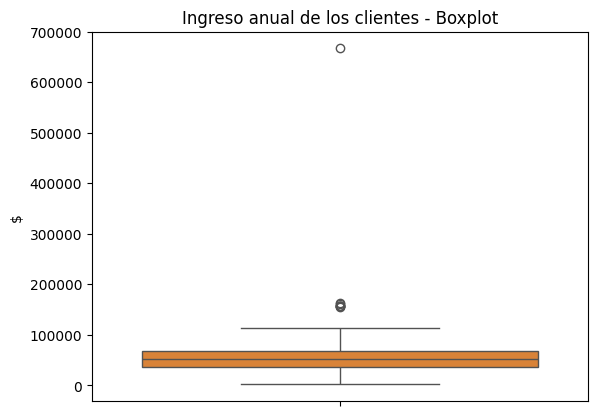

In [23]:
#Boxplot de Ingresos
sns.boxplot(
    data['Income'],
    color = sns.color_palette('YlOrBr')[3]
)

plt.title('Ingreso anual de los clientes - Boxplot')
plt.ylabel('$')
plt.yticks(range(0,700001, 100000))

In [24]:
#Revisando datos del cliente con mayores ingresos
data[data['Income'] > 200000].T

,2233
Education,Licenciatura
Marital_Status,Unión Libre
Income,666666.0
Kidhome,1
Teenhome,0
Dt_Customer,02-06-2013
Recency,23
MntWines,9
MntFruits,14
MntMeatProducts,18


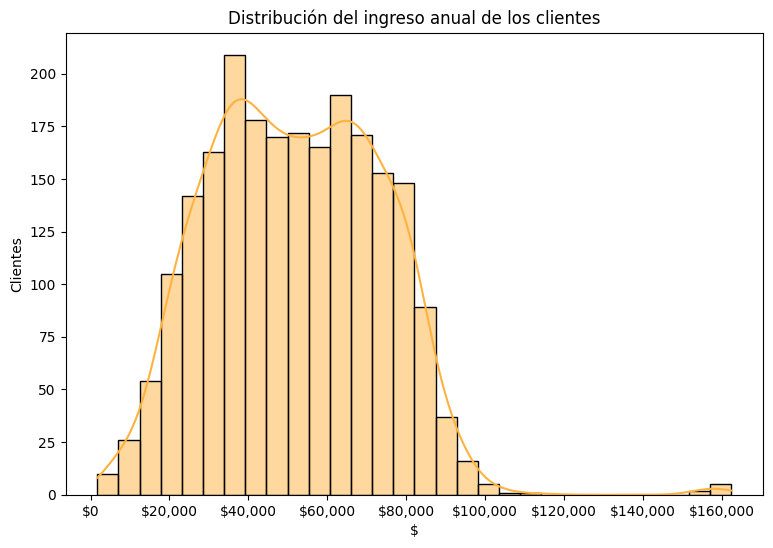

In [25]:
#Histograma de ingresos
#Omitiendo el mayor ingreso para obtener una mejor visualización de la distribución
ingresos_sin_max = data.loc[data['Income'] < 600000, 'Income']

#Gráfico
plt.figure(figsize = (9,6))
sns.histplot(
    ingresos_sin_max,
    bins=30,
    kde=True,
    color = sns.color_palette("YlOrBr")[2]
)

#Títulos
from matplotlib.ticker import StrMethodFormatter
ax = plt.gca()
ax.xaxis.set_major_formatter(StrMethodFormatter('${x:,.0f}'))
plt.title('Distribución del ingreso anual de los clientes')
plt.xlabel('$')
plt.ylabel('Clientes')
plt.show()

### Niños en casa

In [26]:
#Resumen estadístico
data['Kidhome'].describe()

count    2237.000000
mean        0.444345
std         0.538467
min         0.000000
25%         0.000000
50%         0.000000
75%         1.000000
max         2.000000
Name: Kidhome, dtype: float64

In [27]:
#Conteo de niños en casa
data['Kidhome'].value_counts()

Kidhome
0    1291
1     898
2      48
Name: count, dtype: int64

[Text(0, 1, '57.71%'), Text(0, 1, '40.14%'), Text(0, 1, '2.15%')]

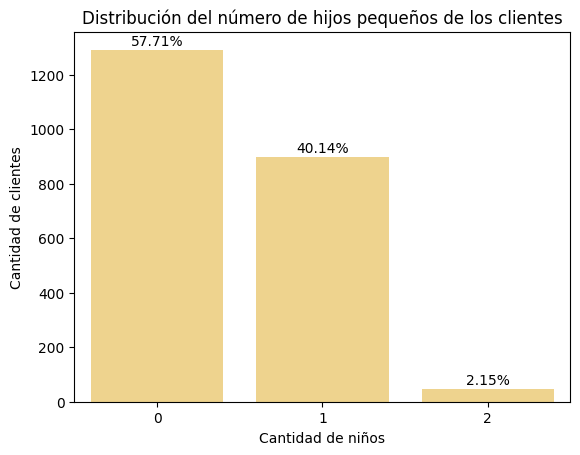

In [28]:
#Gráfico de barras
kids_bar = sns.countplot(
    data = data,
    x = 'Kidhome',
    color = sns.color_palette('YlOrBr')[1]
)

#Etiquetas
plt.title('Distribución del número de hijos pequeños de los clientes')
plt.xlabel('Cantidad de niños')
plt.ylabel('Cantidad de clientes')

#Etiquetas de las barras con porcentajes
total = len(data) #Total de datos
heights = [p.get_height() for p in kids_bar.patches] #Altura de cada barra
labels = [f'{(h/total)*100:.2f}%' for h in heights] #Porcentajes
kids_bar.bar_label(kids_bar.containers[0], labels = labels, padding = 1)

### Adolescentes en casa

In [29]:
#Resumen estadístico
data['Teenhome'].describe()

count    2237.000000
mean        0.506482
std         0.544593
min         0.000000
25%         0.000000
50%         0.000000
75%         1.000000
max         2.000000
Name: Teenhome, dtype: float64

In [30]:
#Conteo
data['Teenhome'].value_counts()

Teenhome
0    1156
1    1029
2      52
Name: count, dtype: int64

[Text(0, 1, '51.68%'), Text(0, 1, '46.00%'), Text(0, 1, '2.32%')]

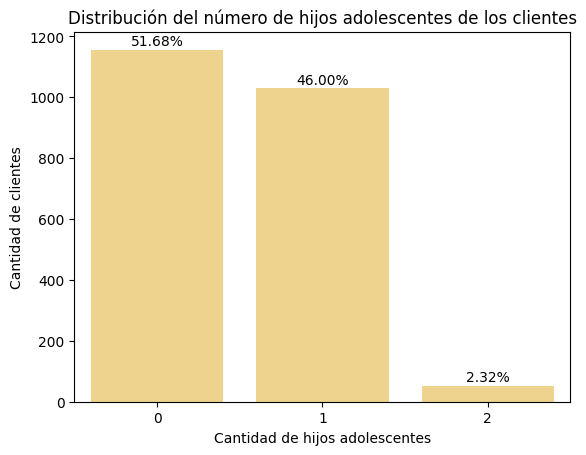

In [31]:
#Gráfico de barras
teen_bar = sns.countplot(
    data = data,
    x = 'Teenhome',
    color = sns.color_palette('YlOrBr')[1]
)

#Etiquetas
plt.title('Distribución del número de hijos adolescentes de los clientes')
plt.xlabel('Cantidad de hijos adolescentes')
plt.ylabel('Cantidad de clientes')

#Etiquetas de las barras con porcentajes
total = len(data) #Total de datos
heights = [p.get_height() for p in teen_bar.patches] #Altura de cada barra
labels = [f'{(h/total)*100:.2f}%' for h in heights] #Porcentajes
teen_bar.bar_label(teen_bar.containers[0], labels = labels, padding = 1)

### Cantidad total de hijos

In [32]:
#Creación de la columna
data['Total_hijos'] = data['Kidhome'] + data['Teenhome']
data.head()

,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Response,Age,Total_hijos
0,Licenciatura,Soltero,58138.0,0,0,04-09-2012,58,635,88,546,...,7,0,0,0,0,0,0,1,69,0
1,Licenciatura,Soltero,46344.0,1,1,08-03-2014,38,11,1,6,...,5,0,0,0,0,0,0,0,72,2
2,Licenciatura,Unión Libre,71613.0,0,0,21-08-2013,26,426,49,127,...,4,0,0,0,0,0,0,0,61,0
3,Licenciatura,Unión Libre,26646.0,1,0,10-02-2014,26,11,4,20,...,6,0,0,0,0,0,0,0,42,1
4,Doctorado,Casado,58293.0,1,0,19-01-2014,94,173,43,118,...,5,0,0,0,0,0,0,0,45,1


In [33]:
#Resumen estadístico
data['Total_hijos'].describe()

count    2237.000000
mean        0.950827
std         0.752037
min         0.000000
25%         0.000000
50%         1.000000
75%         1.000000
max         3.000000
Name: Total_hijos, dtype: float64

[Text(0, 1, '28.48%'),
 Text(0, 1, '50.34%'),
 Text(0, 1, '18.82%'),
 Text(0, 1, '2.37%')]

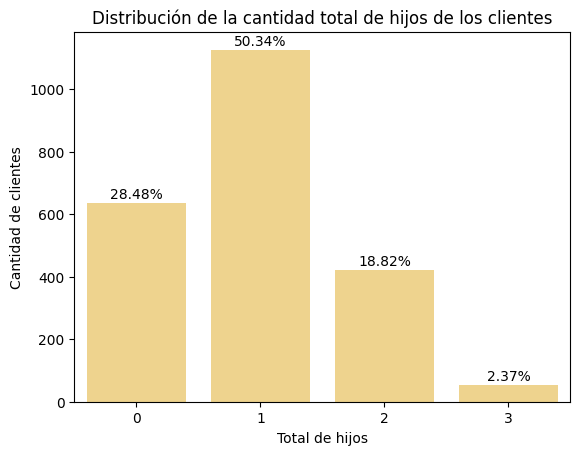

In [34]:
#Gráfico de barras
hijos_bar = sns.countplot(
    data = data,
    x = 'Total_hijos',
    color = sns.color_palette('YlOrBr')[1]
)

#Etiquetas
plt.title('Distribución de la cantidad total de hijos de los clientes')
plt.xlabel('Total de hijos')
plt.ylabel('Cantidad de clientes')

#Etiquetas con porcentajes
total = len(data)
heights = [p.get_height() for p in hijos_bar.patches]
labels = [f'{(h / total) * 100 :.2f}%' for h in heights]
hijos_bar.bar_label(hijos_bar.containers[0], labels = labels, padding = 1)

### Fecha de suscripción a la membresía de la compañía

In [35]:
#Revisando el formato
data['Dt_Customer'].head()

0    04-09-2012
1    08-03-2014
2    21-08-2013
3    10-02-2014
4    19-01-2014
Name: Dt_Customer, dtype: object

In [36]:
#Convirtiendo a tipo fecha
data['Dt_Customer'] = pd.to_datetime(
    data['Dt_Customer'],
    format='%d-%m-%Y'
)

data['Dt_Customer'].head()

0   2012-09-04
1   2014-03-08
2   2013-08-21
3   2014-02-10
4   2014-01-19
Name: Dt_Customer, dtype: datetime64[ns]

In [37]:
#Revisando que no haya nulos
data['Dt_Customer'].isna().sum()

np.int64(0)

In [38]:
#Creando columna de año de regitro
data['Año_registro'] = data['Dt_Customer'].dt.year
data.head()

,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,...,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Response,Age,Total_hijos,Año_registro
0,Licenciatura,Soltero,58138.0,0,0,2012-09-04,58,635,88,546,...,0,0,0,0,0,0,1,69,0,2012
1,Licenciatura,Soltero,46344.0,1,1,2014-03-08,38,11,1,6,...,0,0,0,0,0,0,0,72,2,2014
2,Licenciatura,Unión Libre,71613.0,0,0,2013-08-21,26,426,49,127,...,0,0,0,0,0,0,0,61,0,2013
3,Licenciatura,Unión Libre,26646.0,1,0,2014-02-10,26,11,4,20,...,0,0,0,0,0,0,0,42,1,2014
4,Doctorado,Casado,58293.0,1,0,2014-01-19,94,173,43,118,...,0,0,0,0,0,0,0,45,1,2014


In [39]:
#Resumen estadístico
data['Año_registro'].describe()

count    2237.000000
mean     2013.027716
std         0.684704
min      2012.000000
25%      2013.000000
50%      2013.000000
75%      2013.000000
max      2014.000000
Name: Año_registro, dtype: float64

In [40]:
#Conteo
data['Año_registro'].value_counts().sort_index()

Año_registro
2012     494
2013    1187
2014     556
Name: count, dtype: int64

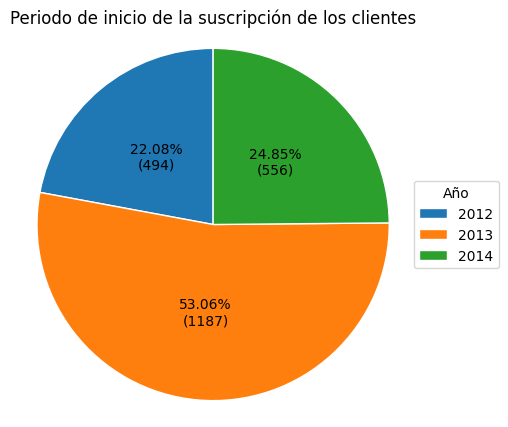

In [41]:
#Gráfico de Pastel
#Conteo
conteo = data['Año_registro'].value_counts().sort_index()
labels = conteo.index
sizes = conteo.values

# Función para mostrar el Porcentaje y la cantidad
def porcentajes(pct):
    total = sum(sizes)
    cantidad = int(round(pct * total / 100.0))
    return f'{pct:.2f}%\n({cantidad:d})'

#Gráfico
plt.figure(figsize=(5, 5))
plt.pie(
    sizes,
    autopct = porcentajes,
    startangle=90,
    pctdistance=0.5,
    labeldistance=1.1,
    wedgeprops={'edgecolor': 'white'}
)

#Leyenda
plt.legend(
    labels,
    title = 'Año',
    loc = 'center left',
    bbox_to_anchor=(1, 0, 0.5, 1)
)

#Título
plt.title('Periodo de inicio de la suscripción de los clientes')
plt.axis('equal')
plt.show()

### Compras recientes

In [42]:
#Contenido de la variable
#Esta variable indica cuántos dían han pasado desde la última compra
data['Recency'].head()

0    58
1    38
2    26
3    26
4    94
Name: Recency, dtype: int64

In [43]:
#Resumen estadístico
data['Recency'].describe().round(2)

count    2237.00
mean       49.10
std        28.96
min         0.00
25%        24.00
50%        49.00
75%        74.00
max        99.00
Name: Recency, dtype: float64

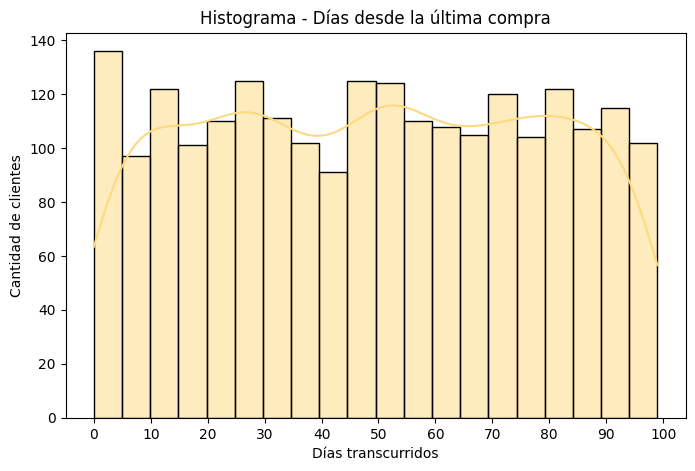

In [44]:
#Histograma
plt.figure(figsize=(8,5))

sns.histplot(
    data = data,
    x = 'Recency',
    bins = 20,
    kde = True,
    color = sns.color_palette('YlOrBr')[1]
)

plt.title('Histograma - Días desde la última compra')
plt.xlabel('Días transcurridos')
plt.ylabel('Cantidad de clientes')
plt.xticks(range(0, 101, 10))

plt.show()

### Gastos

In [45]:
#Resumen estadístico
data[['MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds']].describe().round(2)

,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds
count,2237.00,2237.00,2237.00,2237.00,2237.00,2237.00
mean,304.00,26.27,166.92,37.52,27.07,43.97
std,336.57,39.72,225.66,54.64,41.29,52.05
min,0.00,0.00,0.00,0.00,0.00,0.00
25%,24.00,1.00,16.00,3.00,1.00,9.00
50%,174.00,8.00,67.00,12.00,8.00,24.00
75%,504.00,33.00,232.00,50.00,33.00,56.00
max,1493.00,199.00,1725.00,259.00,263.00,362.00


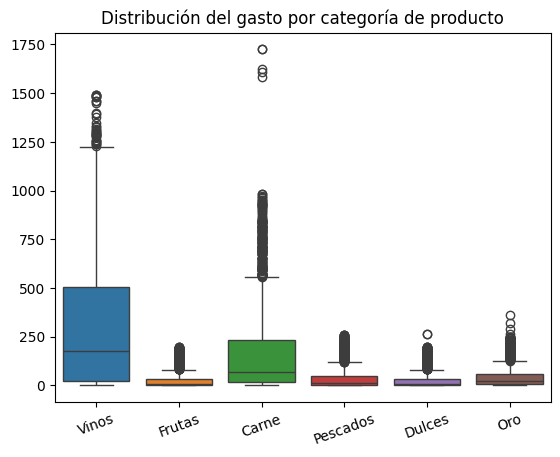

In [46]:
#Boxplots
gastos_cols = ['MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds']

gastos_box = sns.boxplot(
    data = data[gastos_cols]
    )

gastos_box.set_xticks([0, 1, 2, 3, 4, 5], labels= ['Vinos', 'Frutas', 'Carne', 'Pescados', 'Dulces', 'Oro'])
plt.xticks(rotation=20)
plt.title('Distribución del gasto por categoría de producto')
plt.show()

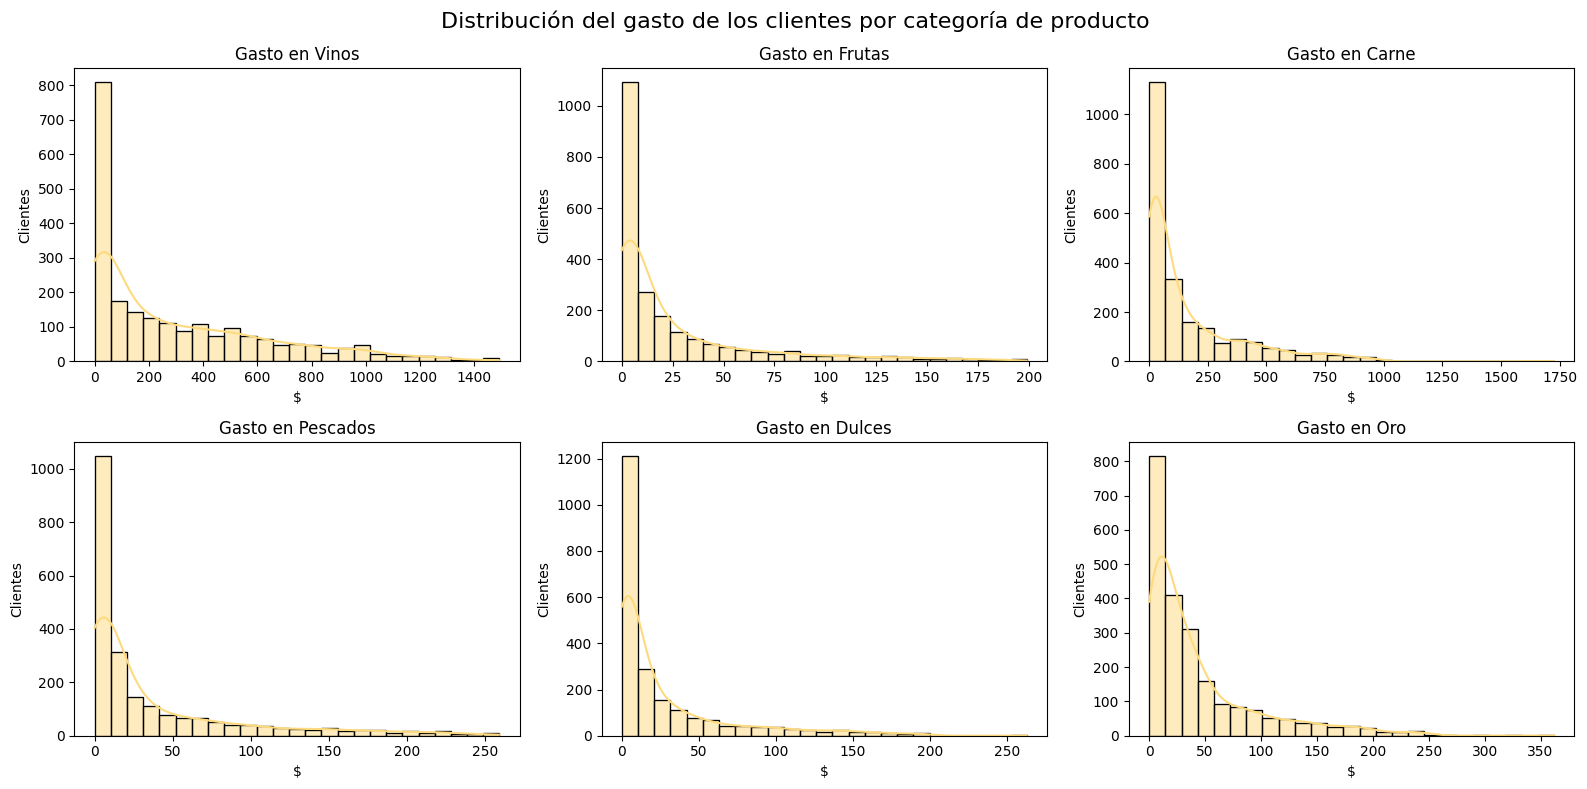

In [47]:
#Histogramas
titulos = ['Vinos', 'Frutas', 'Carne', 'Pescados', 'Dulces', 'Oro']

fig, axes = plt.subplots(2, 3, figsize=(16, 8))

for ax, col, title in zip(axes.flat, gastos_cols, titulos):
    sns.histplot(
        data = data,
        x = col,
        bins = 25,
        kde = True,
        ax = ax,
        color = sns.color_palette('YlOrBr')[1]
    )

    ax.set_title(f'Gasto en {title}')
    ax.set_xlabel('$')
    ax.set_ylabel('Clientes')

plt.suptitle('Distribución del gasto de los clientes por categoría de producto', fontsize=16)
plt.tight_layout()
plt.show()

In [48]:
#Creación de variable de gasto total
data['Total_gasto'] = data[gastos_cols].sum(axis=1)
data.head()

,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,...,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Response,Age,Total_hijos,Año_registro,Total_gasto
0,Licenciatura,Soltero,58138.0,0,0,2012-09-04,58,635,88,546,...,0,0,0,0,0,1,69,0,2012,1617
1,Licenciatura,Soltero,46344.0,1,1,2014-03-08,38,11,1,6,...,0,0,0,0,0,0,72,2,2014,27
2,Licenciatura,Unión Libre,71613.0,0,0,2013-08-21,26,426,49,127,...,0,0,0,0,0,0,61,0,2013,776
3,Licenciatura,Unión Libre,26646.0,1,0,2014-02-10,26,11,4,20,...,0,0,0,0,0,0,42,1,2014,53
4,Doctorado,Casado,58293.0,1,0,2014-01-19,94,173,43,118,...,0,0,0,0,0,0,45,1,2014,422


In [49]:
#Resumen estadístico
data['Total_gasto'].describe()

count    2237.000000
mean      605.743406
std       601.840466
min         5.000000
25%        69.000000
50%       396.000000
75%      1045.000000
max      2525.000000
Name: Total_gasto, dtype: float64

Text(0, 0.5, 'Gasto total')

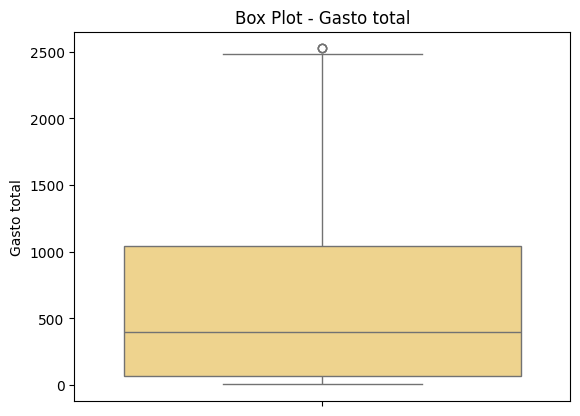

In [50]:
#Boxplot
sns.boxplot(
    data = data['Total_gasto'],
    color = sns.color_palette('YlOrBr')[1]
)

plt.title('Box Plot - Gasto total')
plt.ylabel('Gasto total')

Text(0.5, 0, '$')

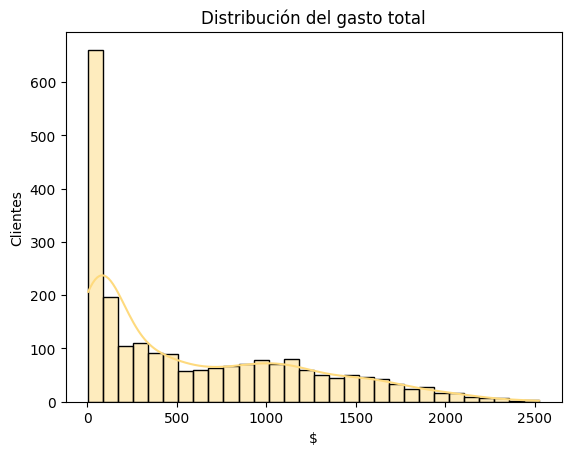

In [51]:
#Histograma
sns.histplot(
    data = data,
    x = 'Total_gasto',
    bins=30,
    kde=True,
    color = sns.color_palette('YlOrBr')[1]
)

plt.title('Distribución del gasto total')
plt.ylabel('Clientes')
plt.xlabel('$')

### Compras

In [52]:
#Resumen estadístico
data[['NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases']].describe().round(2)

,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases
count,2237.00,2237.00,2237.00,2237.00
mean,2.33,4.09,2.66,5.79
std,1.93,2.78,2.92,3.25
min,0.00,0.00,0.00,0.00
25%,1.00,2.00,0.00,3.00
50%,2.00,4.00,2.00,5.00
75%,3.00,6.00,4.00,8.00
max,15.00,27.00,28.00,13.00


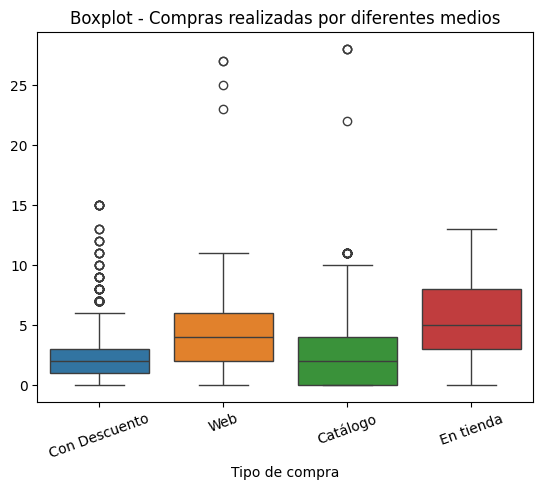

In [53]:
#Boxplots
compras_cols = ['NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases']
compras_labels = ['Con Descuento', 'Web', 'Catálogo', 'En tienda']

compras_box = sns.boxplot(
    data = data[compras_cols]
    )

plt.title('Boxplot - Compras realizadas por diferentes medios')
compras_box.set_xticks([0, 1, 2, 3], labels = compras_labels)
plt.xticks(rotation=20)
plt.xlabel('Tipo de compra')
plt.show()

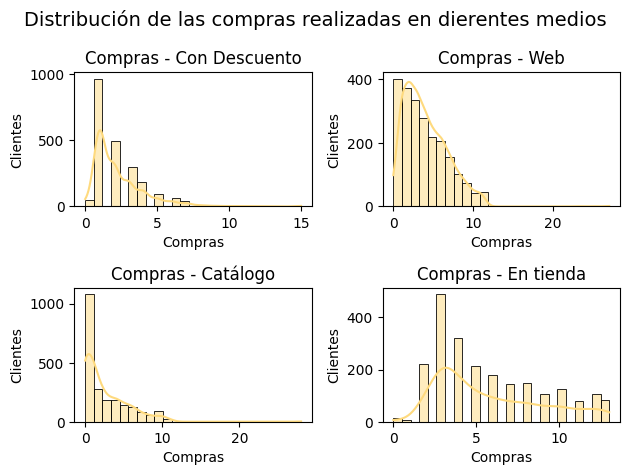

In [54]:
#Histogramas
fig, axes = plt.subplots(2, 2)

for ax, col, title in zip(axes.flat, compras_cols, compras_labels):
    sns.histplot(
        data = data,
        x = col,
        bins = 25,
        kde = True,
        ax = ax,
        color = sns.color_palette('YlOrBr')[1]
    )

    ax.set_title(f'Compras - {title}')
    ax.set_xlabel('Compras')
    ax.set_ylabel('Clientes')

plt.suptitle('Distribución de las compras realizadas en dierentes medios', fontsize=14)
plt.tight_layout()
plt.show()

In [55]:
#Creación de variable de total de compras
data['Total_compras'] = data[compras_cols].sum(axis=1)
data.head()

,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,...,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Response,Age,Total_hijos,Año_registro,Total_gasto,Total_compras
0,Licenciatura,Soltero,58138.0,0,0,2012-09-04,58,635,88,546,...,0,0,0,0,1,69,0,2012,1617,25
1,Licenciatura,Soltero,46344.0,1,1,2014-03-08,38,11,1,6,...,0,0,0,0,0,72,2,2014,27,6
2,Licenciatura,Unión Libre,71613.0,0,0,2013-08-21,26,426,49,127,...,0,0,0,0,0,61,0,2013,776,21
3,Licenciatura,Unión Libre,26646.0,1,0,2014-02-10,26,11,4,20,...,0,0,0,0,0,42,1,2014,53,8
4,Doctorado,Casado,58293.0,1,0,2014-01-19,94,173,43,118,...,0,0,0,0,0,45,1,2014,422,19


In [56]:
#Resumen estadístico
data['Total_compras'].describe()

count    2237.000000
mean       14.870809
std         7.676593
min         0.000000
25%         8.000000
50%        15.000000
75%        21.000000
max        44.000000
Name: Total_compras, dtype: float64

Text(0, 0.5, 'Compras')

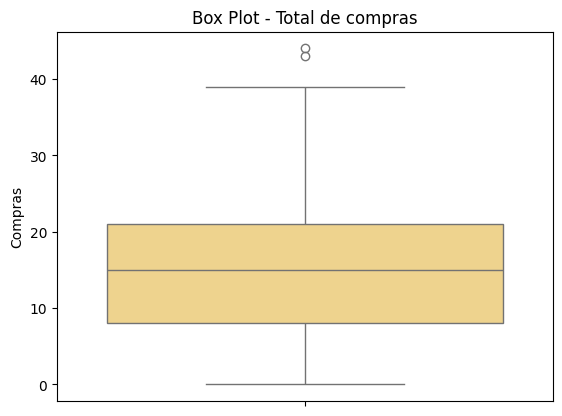

In [57]:
#Boxplot
sns.boxplot(
    data = data['Total_compras'],
    color = sns.color_palette('YlOrBr')[1]
)

plt.title('Box Plot - Total de compras')
plt.ylabel('Compras')

Text(0.5, 0, 'Compras')

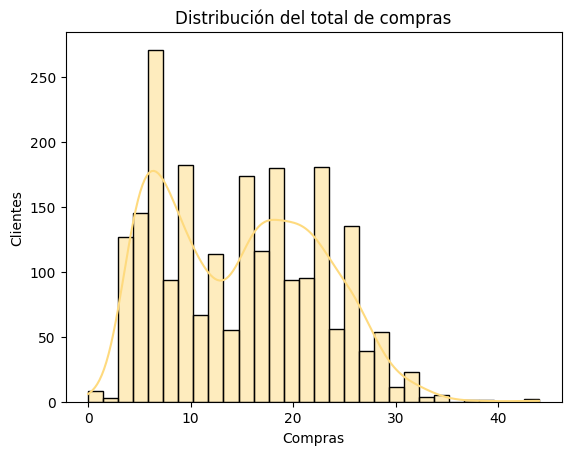

In [58]:
#Histograma
sns.histplot(
    data = data,
    x = 'Total_compras',
    bins=30,
    kde=True,
    color = sns.color_palette('YlOrBr')[1]
)

plt.title('Distribución del total de compras')
plt.ylabel('Clientes')
plt.xlabel('Compras')

### Visitas a la página web por mes

In [59]:
#Resumen estadístico
data['NumWebVisitsMonth'].describe()

count    2237.000000
mean        5.319177
std         2.426386
min         0.000000
25%         3.000000
50%         6.000000
75%         7.000000
max        20.000000
Name: NumWebVisitsMonth, dtype: float64

Text(0, 0.5, 'Visitas')

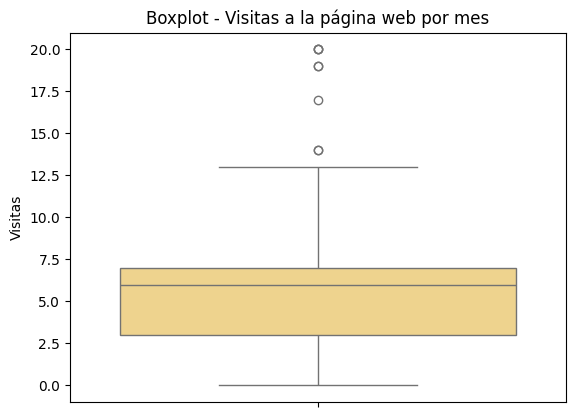

In [60]:
#Boxplot
sns.boxplot(
    data = data['NumWebVisitsMonth'],
    color = sns.color_palette('YlOrBr')[1]
)

plt.title('Boxplot - Visitas a la página web por mes')
plt.ylabel('Visitas')

### Compras con oferta

In [61]:
#Creación de una columna para contar el número de ofertas aceptadas
cmp_cols = [
    'AcceptedCmp1',
    'AcceptedCmp2',
    'AcceptedCmp3',
    'AcceptedCmp4',
    'AcceptedCmp5',
    'Response'
]

data['Campañas_aceptadas'] = data[cmp_cols].sum(axis=1)
data['Campañas_aceptadas'].describe()

count    2237.000000
mean        0.447027
std         0.890964
min         0.000000
25%         0.000000
50%         0.000000
75%         1.000000
max         5.000000
Name: Campañas_aceptadas, dtype: float64

[Text(0, 1, '72.82%'),
 Text(0, 1, '16.50%'),
 Text(0, 1, '6.35%'),
 Text(0, 1, '2.28%'),
 Text(0, 1, '1.61%'),
 Text(0, 1, '0.45%')]

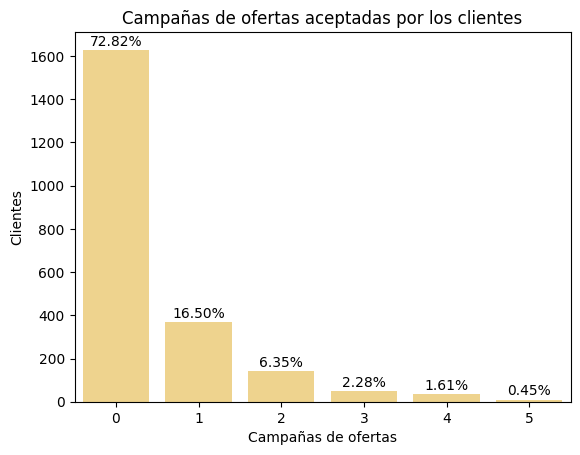

In [62]:
#Gráfico de barras
bar_cmp = sns.countplot(
    data = data,
    x = 'Campañas_aceptadas',
    color = sns.color_palette('YlOrBr')[1]
)

plt.title('Campañas de ofertas aceptadas por los clientes')
plt.xlabel('Campañas de ofertas')
plt.ylabel('Clientes')

total = len(data)
heights = [p.get_height() for p in bar_cmp.patches]
labels = [f'{(h / total) * 100 :.2f}%' for h in heights]
bar_cmp.bar_label(bar_cmp.containers[0], labels = labels, padding = 1)

### Quejas

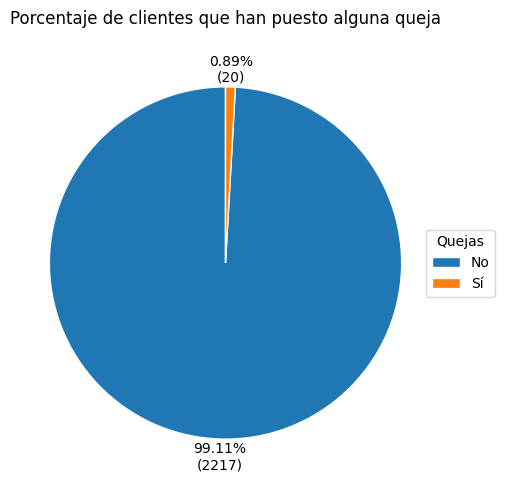

In [63]:
#Gráfico de pastel
#Conteo
conteo = data['Complain'].value_counts()
labels = ['No', 'Sí']
sizes = conteo.values

# Función personalizada para mostrar el Porcentaje y la cantidad
def porcentajes(pct):
    total = sum(sizes)
    cantidad = int(round(pct * total / 100.0))
    return f'{pct:.2f}%\n({cantidad:d})'

#Gráfico
plt.figure(figsize=(5, 6))
plt.pie(
    sizes,
    autopct = porcentajes,
    startangle=90,
    pctdistance=1.1,
    labeldistance=1.1,
    wedgeprops={'edgecolor': 'white'}
)

#Leyenda
plt.legend(
    labels,
    title = 'Quejas',
    loc = 'center left',
    bbox_to_anchor=(1, 0, 0.5, 1)
)

#Título
plt.title('Porcentaje de clientes que han puesto alguna queja')
plt.axis('equal')
plt.show()

### Relaciones importantes entre variables

#### Ingresos y Gasto total

In [64]:
#Correlación
data['Income'].corr(data['Total_gasto']).round(2)

np.float64(0.67)

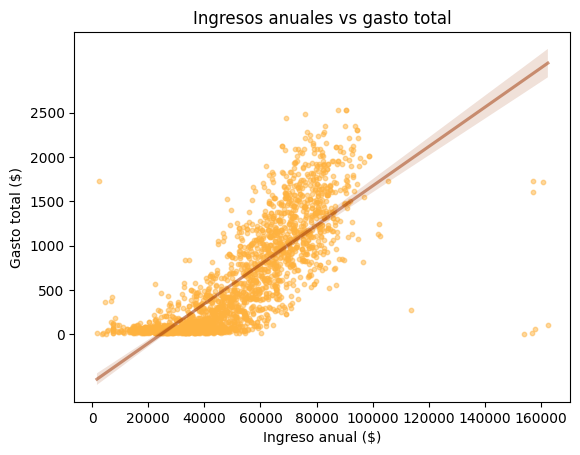

In [65]:
#Gráfico de regresión
sns.regplot(
    data = data[data['Income'] < 200000],
    x = 'Income',
    y = 'Total_gasto',
    scatter_kws = {
        'alpha' : 0.5,
        's' : 10,
        'color' : sns.color_palette('YlOrBr')[2]
    },
    line_kws={
        'color':sns.color_palette('YlOrBr')[5],
        'alpha' : 0.5
    }
)

plt.title('Ingresos anuales vs gasto total')
plt.xlabel('Ingreso anual ($)')
plt.ylabel('Gasto total ($)')
plt.yticks(range(0, 3000, 500))

plt.show()

#### Ingresos y total de compras

In [66]:
#Correlación
data['Income'].corr(data['Total_compras']).round(2)

np.float64(0.57)

Text(0, 0.5, 'Total de compras realizadas')

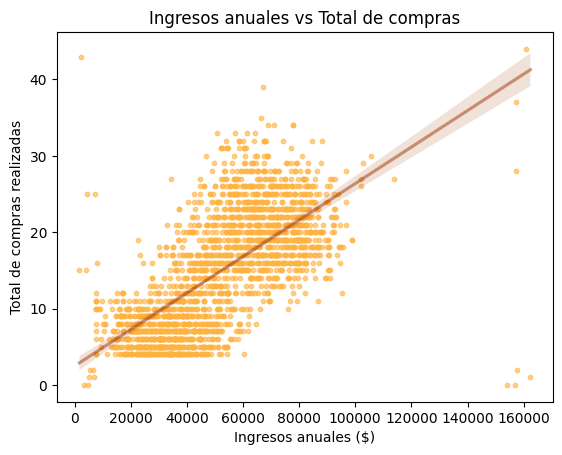

In [67]:
#Gráfico de regresión
sns.regplot(
    data = data[data['Income'] < 200000],
    x = 'Income',
    y = 'Total_compras',
    scatter_kws = {
        'alpha' : 0.6,
        's' : 10,
        'color' : sns.color_palette('YlOrBr')[2]
    },
    line_kws={
        'color':sns.color_palette('YlOrBr')[5],
        'alpha' : 0.5
    }
)

plt.title('Ingresos anuales vs Total de compras')
plt.xlabel('Ingresos anuales ($)')
plt.ylabel('Total de compras realizadas')

#### Ingresos y nivel educativo

In [68]:
#Resumen estadístico
data['Income'].groupby(data['Education']).describe().round(2)

,count,mean,std,min,25%,50%,75%,max
Education,,,,,,,,
Básica,54.0,20306.26,6235.07,7500.0,15405.25,20744.0,24882.00,34445.0
Doctorado,480.0,56088.26,20596.43,4023.0,40424.25,55185.0,69087.50,162397.0
Licenciatura,1116.0,52720.37,28177.19,1730.0,34834.50,52028.5,69930.50,666666.0
Maestría,365.0,52917.53,20157.79,6560.0,37760.00,50943.0,66726.00,157733.0
Posgrado,198.0,47625.33,22199.28,7500.0,27113.50,46805.0,65439.75,96547.0


Text(0, 0.5, 'Ingreso anual ($)')

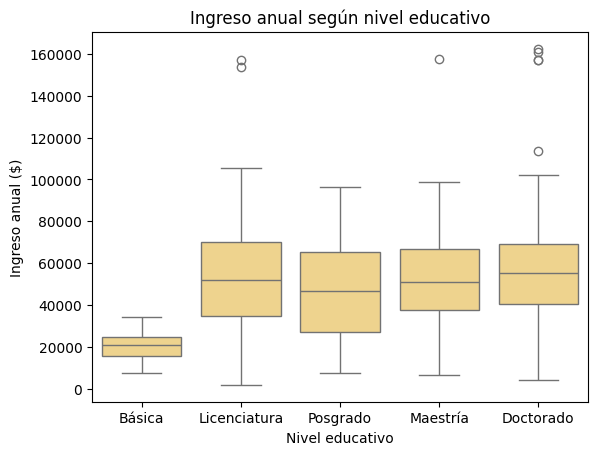

In [69]:
#Boxplot
sns.boxplot(
    data = data[data['Income'] < 200000],
    x = 'Education',
    y = 'Income',
    order=['Básica', 'Licenciatura', 'Posgrado', 'Maestría', 'Doctorado'],
    color = sns.color_palette('YlOrBr')[1]
)

plt.title('Ingreso anual según nivel educativo')
plt.xlabel('Nivel educativo')
plt.ylabel('Ingreso anual ($)')

#### Gasto total y edad

In [70]:
#Correlación
data['Total_gasto'].corr(data['Age']).round(2)

np.float64(0.11)

Text(0, 0.5, 'Gasto total ($)')

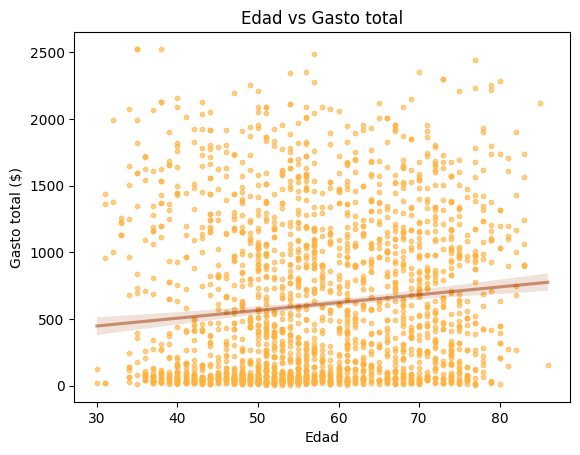

In [71]:
#Gráfico de regresión
sns.regplot(
    data = data,
    x = 'Age',
    y = 'Total_gasto',
    scatter_kws = {
        'alpha' : 0.6,
        's' : 10,
        'color' : sns.color_palette('YlOrBr')[2]
    },
    line_kws={
        'color':sns.color_palette('YlOrBr')[5],
        'alpha' : 0.5
    }
)

plt.title('Edad vs Gasto total')
plt.xlabel('Edad')
plt.ylabel('Gasto total ($)')

#### Hijos y gasto total

In [72]:
#Correlación
data['Total_gasto'].corr(data['Total_hijos']).round(2)

np.float64(-0.5)

Text(0, 0.5, 'Gasto total ($)')

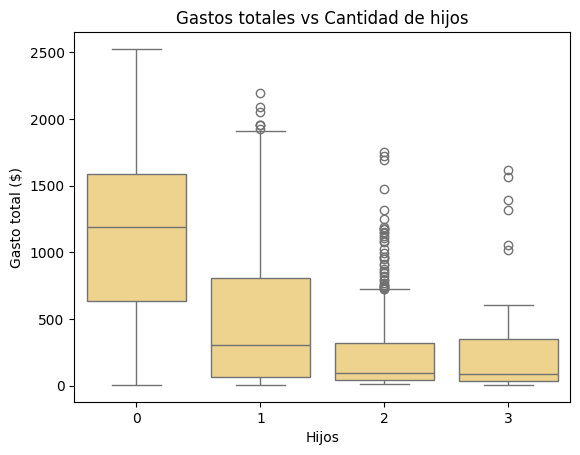

In [73]:
#Boxplot
sns.boxplot(
    data = data,
    x = 'Total_hijos',
    y = 'Total_gasto',
    color = sns.color_palette('YlOrBr')[1]
)

plt.title('Gastos totales vs Cantidad de hijos')
plt.xlabel('Hijos')
plt.ylabel('Gasto total ($)')

#### Campañas de ofertas y gastos totales

In [74]:
#Correlación
data['Total_gasto'].corr(data['Campañas_aceptadas']).round(2)

np.float64(0.46)

Text(0, 0.5, 'Gasto total ($)')

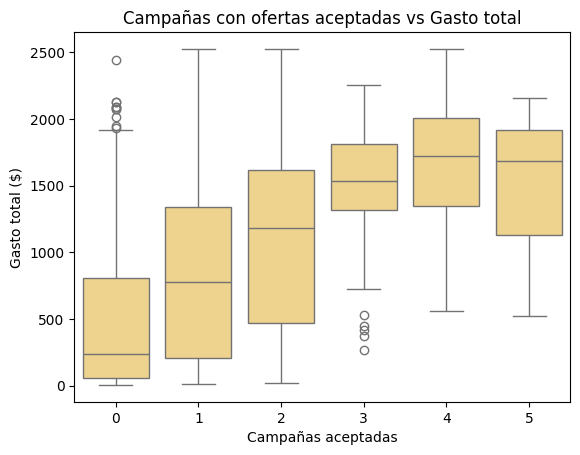

In [75]:
#Boxplot
sns.boxplot(
    data = data,
    x = 'Campañas_aceptadas',
    y = 'Total_gasto',
    color = sns.color_palette('YlOrBr')[1]
)

plt.title('Campañas con ofertas aceptadas vs Gasto total')
plt.xlabel('Campañas aceptadas')
plt.ylabel('Gasto total ($)')

#### Visitas a la página web y compras en la web

In [76]:
#Correlación
data['NumWebVisitsMonth'].corr(data['NumWebPurchases']).round(2)

np.float64(-0.06)

Text(0, 0.5, 'Compras realizadas')

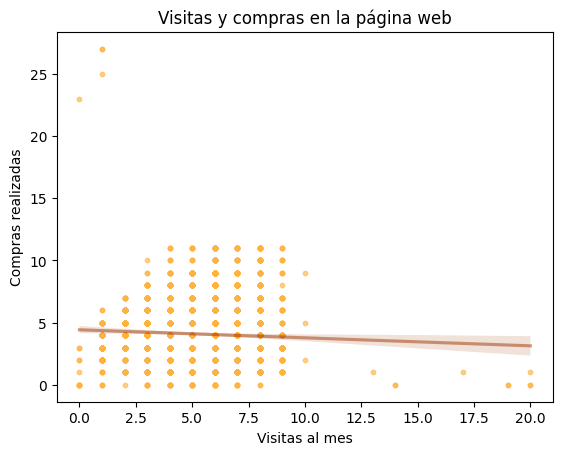

In [77]:
#Gráfico de regresión
sns.regplot(
    data = data,
    x = 'NumWebVisitsMonth',
    y = 'NumWebPurchases',
    scatter_kws = {
        'alpha' : 0.6,
        's' : 10,
        'color' : sns.color_palette('YlOrBr')[2]
    },
    line_kws={
        'color':sns.color_palette('YlOrBr')[5],
        'alpha' : 0.5
    }
)

plt.title('Visitas y compras en la página web')
plt.xlabel('Visitas al mes')
plt.ylabel('Compras realizadas')

#### Correlación

Text(0.5, 1.0, 'Matriz de correlación de las variables principales')

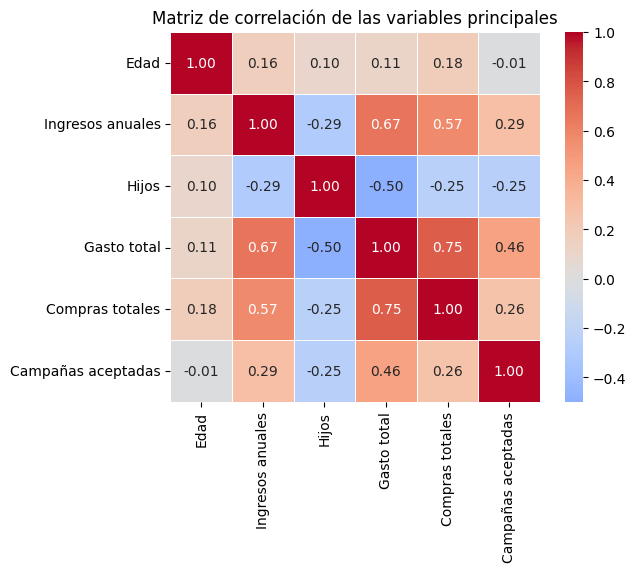

In [78]:
#Matriz de correlación
corr_cols = [
    'Age',
    'Income',
    'Total_hijos',
    'Total_gasto',
    'Total_compras',
    'Campañas_aceptadas'
]

corr = data[corr_cols].corr()
ax = sns.heatmap(
    corr,
    annot = True,
    cmap = 'coolwarm',
    center = 0,
    fmt = '.2f',
    linewidths = 0.5,
    square = True
)

#Etiquetas
nuevas_etiquetas = {
    'Age': 'Edad',
    'Income': 'Ingresos anuales',
    'Total_hijos': 'Hijos',
    'Total_gasto': 'Gasto total',
    'Total_compras': 'Compras totales',
    'Campañas_aceptadas': 'Campañas aceptadas'
}
ax.set_xticklabels([nuevas_etiquetas.get(x, x) for x in corr.columns])
ax.set_yticklabels([nuevas_etiquetas.get(x, x) for x in corr.index])
plt.title('Matriz de correlación de las variables principales')

## Modelo

### Selección de variables

In [79]:
#Columnas
data.columns

Index(['Education', 'Marital_Status', 'Income', 'Kidhome', 'Teenhome',
       'Dt_Customer', 'Recency', 'MntWines', 'MntFruits', 'MntMeatProducts',
       'MntFishProducts', 'MntSweetProducts', 'MntGoldProds',
       'NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases',
       'NumStorePurchases', 'NumWebVisitsMonth', 'AcceptedCmp3',
       'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1', 'AcceptedCmp2',
       'Complain', 'Response', 'Age', 'Total_hijos', 'Año_registro',
       'Total_gasto', 'Total_compras', 'Campañas_aceptadas'],
      dtype='object')

In [80]:
#Columnas numéricas
num_cols = [
    'Age',
    'Income',
    'Total_hijos',
    'Total_gasto',
    'Total_compras',
    'Campañas_aceptadas'
]

#Columnas categóricas
cat_cols = [
    'Education',
    'Marital_Status'
]

# Dataset para clustering
X = data[num_cols + cat_cols]
X.head()

,Age,Income,Total_hijos,Total_gasto,Total_compras,Campañas_aceptadas,Education,Marital_Status
0,69,58138.0,0,1617,25,1,Licenciatura,Soltero
1,72,46344.0,2,27,6,0,Licenciatura,Soltero
2,61,71613.0,0,776,21,0,Licenciatura,Unión Libre
3,42,26646.0,1,53,8,0,Licenciatura,Unión Libre
4,45,58293.0,1,422,19,0,Doctorado,Casado


### Preprocesamiento

In [81]:
#Columnas numéricas
num_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy = 'median')),
    ('scaler', StandardScaler())
])

#Columnas categóricas
cat_transformer = Pipeline([
    ('encoder', OneHotEncoder(handle_unknown = 'ignore', sparse_output = False))
])

#Transformación
preprocessor = ColumnTransformer([
        ('num', num_transformer, num_cols),
        ('cat', cat_transformer, cat_cols)
])

In [82]:
#Procesando X
X_processed = preprocessor.fit_transform(X)

#Convirtiendo a DF
feature_names = preprocessor.get_feature_names_out()
X_processed = pd.DataFrame(
    X_processed,
    columns=feature_names,
    index=X.index
)

#Revisión
X_processed.head()

,num__Age,num__Income,num__Total_hijos,num__Total_gasto,num__Total_compras,num__Campañas_aceptadas,cat__Education_Básica,cat__Education_Doctorado,cat__Education_Licenciatura,cat__Education_Maestría,cat__Education_Posgrado,cat__Marital_Status_Casado,cat__Marital_Status_Divorciado,cat__Marital_Status_Soltero,cat__Marital_Status_Unión Libre,cat__Marital_Status_Viudo
0,1.017296,0.236072,-1.264618,1.680649,1.319785,0.620785,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1,1.273722,-0.234979,1.395420,-0.961838,-1.155824,-0.501847,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
2,0.333495,0.774261,-1.264618,0.282956,0.798604,-0.501847,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3,-1.290534,-1.021713,0.065401,-0.918627,-0.895234,-0.501847,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,-1.034108,0.242262,0.065401,-0.305371,0.538014,-0.501847,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0


In [83]:
#Comprobación de valores nulos
X_processed.isna().sum().sum()

np.int64(0)

In [84]:
#Dimensiones
X_processed.shape

(2237, 16)

### K-Means

In [85]:
#Técnica del codo
#Lista para guardar los valores de la cantidad de clústeres
n_grupos = []

for cluster in range (1,11):
    #Algorítmo
    kmeans = KMeans(
        n_clusters = cluster, #Cantidad de clústers
        init = 'k-means++', #Inicializando los centroides
        max_iter = 300, #Número máximo de iteraciones
        n_init = 10, #Cuántas veces se ejecuta K-Means con diferentes centroides
        random_state = 42
    )
    
    kmeans.fit(X_processed) #Entrenando modelo
    n_grupos.append(kmeans.inertia_) #Guardando las inercias en la lista

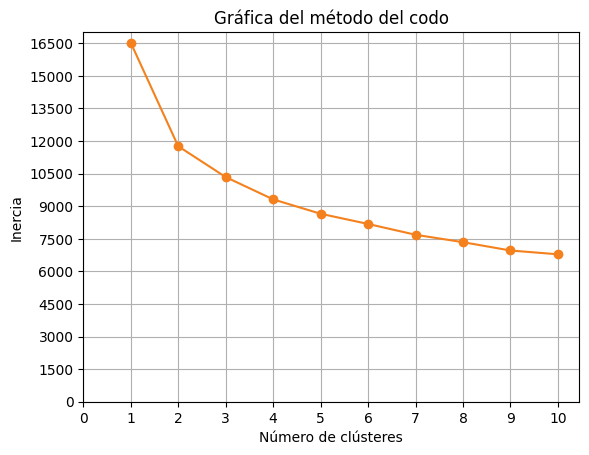

In [86]:
#Gráfica del codo
plt.plot(
    range(1,11),
    n_grupos,
    marker = 'o',
    color = sns.color_palette('YlOrBr')[3]
    )

plt.grid()
plt.title('Gráfica del método del codo')
plt.xlabel('Número de clústeres')
plt.ylabel('Inercia')
plt.xticks(range(0,11,1))
plt.yticks(range(0,17001,1500))
plt.show()

In [87]:
#Silhouette Score
#Lista para guardar los resultados de los silhouette score
sscores = []

#Calculando Silhoutte sscores
for cluster in range(2,11):
    kmeans = KMeans(
        n_clusters = cluster,
        n_init=10,
        random_state = 42
    )
    labels = kmeans.fit_predict(X_processed)
    score = silhouette_score(X_processed, labels)
    sscores.append(score)

#Scores
sscores

[0.26923705723662106,
 0.23824434255557664,
 0.18727335358670527,
 0.16985058055437177,
 0.1720126730633525,
 0.16487149181995128,
 0.16828423492201938,
 0.16202372564405898,
 0.13371676737547944]

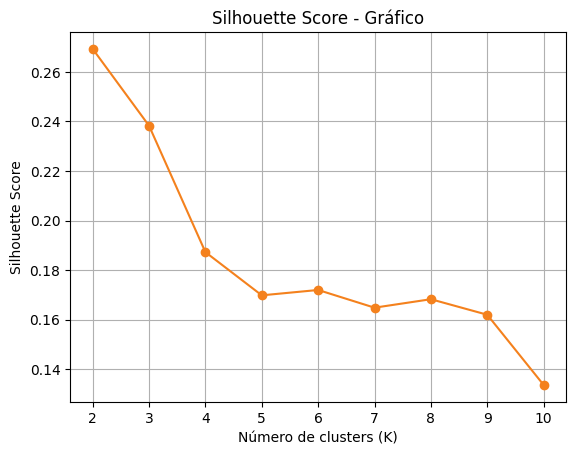

In [88]:
#Graficando Silhoutte Scores
plt.plot(
    range(2,11),
    sscores,
    marker='o',
    color = sns.color_palette('YlOrBr')[3]
)

plt.grid()
plt.title('Silhouette Score - Gráfico')
plt.xlabel('Número de clusters (K)')
plt.ylabel('Silhouette Score')
plt.xticks(range(2,11,1))

plt.show()

In [89]:
#Modelo 1
kmeans = KMeans(
    n_clusters=2,
    random_state=42,
    n_init=10
)

#Resultados
segmentos = kmeans.fit_predict(X_processed)

In [90]:
#Conteo de los grupos resultantes
data['Cluster_KMeans'] = segmentos
data['Cluster_KMeans'].value_counts()

Cluster_KMeans
1    1243
0     994
Name: count, dtype: int64

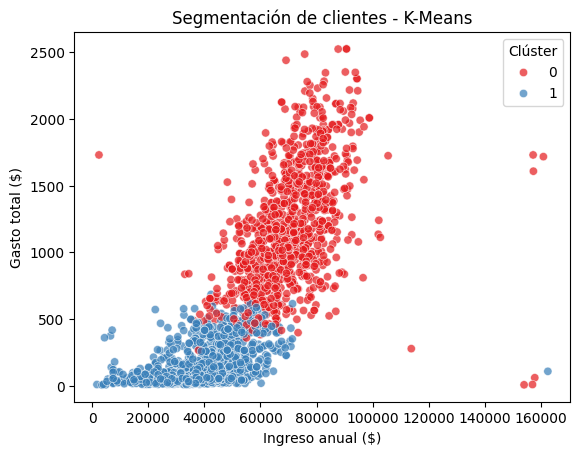

In [91]:
#Grafica de grupos tomando en cuenta el ingreso anual y el gasto total
#Colores a usar
colores = ['red', 'blue']

#Gráfico de dispersión
sns.scatterplot(
    data = data[data['Income'] < 200000],
    x = 'Income',
    y = 'Total_gasto',
    hue = 'Cluster_KMeans',
    palette='Set1',
    alpha=0.7
)

plt.title('Segmentación de clientes - K-Means')
plt.xlabel('Ingreso anual ($)')
plt.ylabel('Gasto total ($)')
plt.legend(title = 'Clúster')

plt.show()

In [92]:
#Promedio y mediana de las columnas numéricas agrupadas por clústeres
cluster_profile = (
    data.groupby('Cluster_KMeans')[num_cols].agg(['mean', 'median']).round(2)
)

cluster_profile.T

Cluster_KMeans                    0         1
Age                mean       59.31     55.33
                   median     59.00     54.00
Income             mean    71084.76  37090.45
                   median  70172.00  36959.00
Total_hijos        mean        0.57      1.25
                   median      0.50      1.00
Total_gasto        mean     1175.26    150.32
                   median   1120.00     79.00
Total_compras      mean       21.60      9.49
                   median     21.00      8.00
Campañas_aceptadas mean        0.79      0.17
                   median      0.00      0.00

### Clustering Jerárquico

([<matplotlib.axis.YTick at 0x186db318050>,
 [Text(0, 0, '0'),
  Text(0, 10, '10'),
  Text(0, 20, '20'),
  Text(0, 30, '30'),
  Text(0, 40, '40'),
  Text(0, 50, '50'),
  Text(0, 60, '60'),
  Text(0, 70, '70'),
  Text(0, 80, '80'),
  Text(0, 90, '90')])

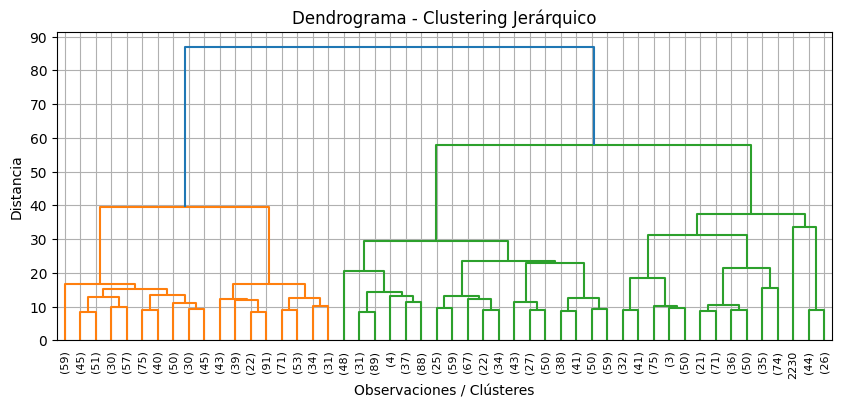

In [93]:
#Matriz de enlaces
link_mat = linkage(
    X_processed,
    method = 'ward'
)

#Dendrograma
plt.figure(figsize=(10,4))
dendrogram(
    link_mat,
    truncate_mode = 'lastp',
    p = 50
)

plt.grid()
plt.title('Dendrograma - Clustering Jerárquico')
plt.xlabel('Observaciones / Clústeres')
plt.ylabel('Distancia')
plt.yticks(range(0, 91, 10))

In [94]:
#Modelo
cja = AgglomerativeClustering(
    n_clusters=2,
    linkage='ward'
)

#Entrenamiento
clusters_cja = cja.fit_predict(X_processed)

#Conteo
data['Clusters_Jerarquicos'] = clusters_cja
data['Clusters_Jerarquicos'].value_counts()

Clusters_Jerarquicos
0    1371
1     866
Name: count, dtype: int64

In [95]:
#Comparando modelos
pd.crosstab(
    data['Cluster_KMeans'],
    data['Clusters_Jerarquicos'],
    margins=True
)

Clusters_Jerarquicos,0,1,All
Cluster_KMeans,,,
0,993,1,994
1,378,865,1243
All,1371,866,2237


In [96]:
#Promedio y mediana de las columnas numéricas agrupadas por clústeres
cluster_profile = (
    data.groupby('Clusters_Jerarquicos')[num_cols].agg(['mean', 'median']).round(2)
)

cluster_profile.T

Clusters_Jerarquicos              0         1
Age                mean       59.28     53.64
                   median     59.00     53.00
Income             mean    64020.72  33519.78
                   median  64758.50  33581.00
Total_hijos        mean        0.71      1.33
                   median      1.00      1.00
Total_gasto        mean      936.87     81.52
                   median    907.00     57.00
Total_compras      mean       19.54      7.48
                   median     20.00      7.00
Campañas_aceptadas mean        0.62      0.17
                   median      0.00      0.00

In [97]:
#Silhouette Score del clustering jerárquico
silhouette_cja = silhouette_score(
    X_processed,
    clusters_cja
)

print(f'Silhouette Score: {silhouette_cja:.3f}')

Silhouette Score: 0.202


### DBSCAN

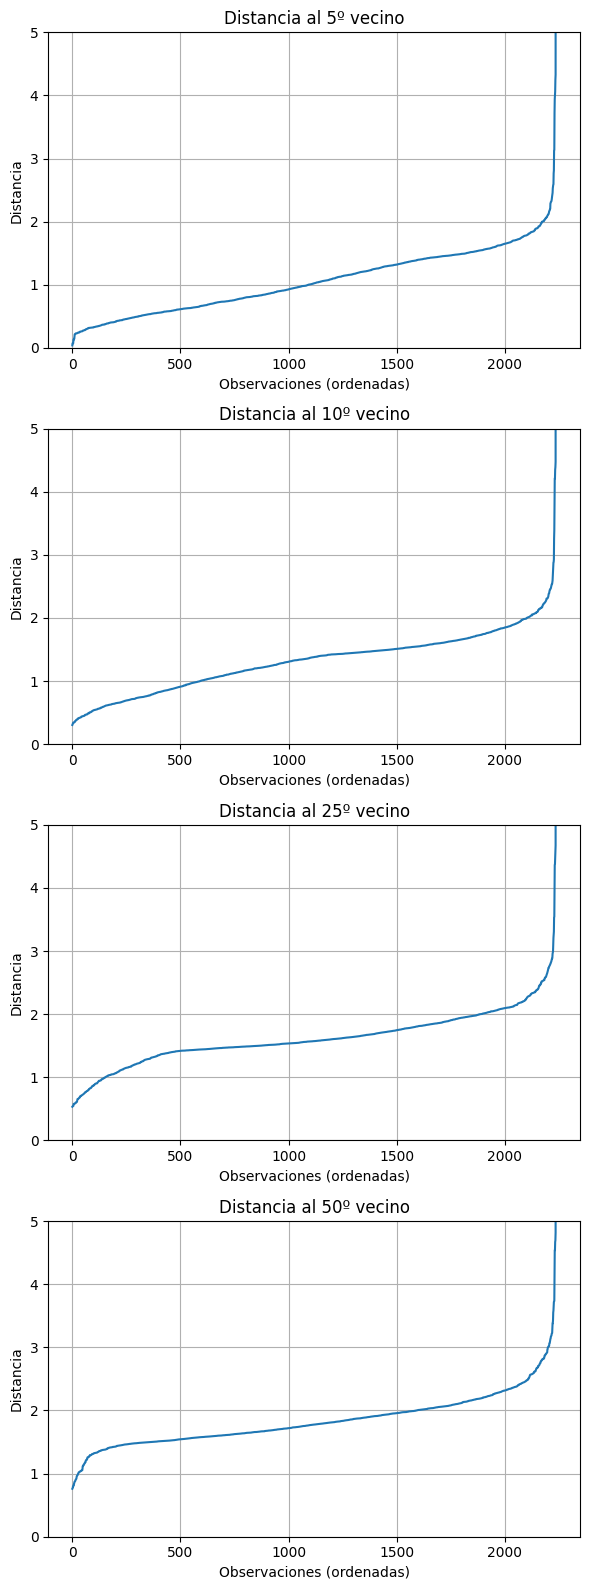

In [98]:
#Gráfico de distancia al K-Vecino
#Configuración
min_samples_valores = [5, 10, 25, 50]
n_filas = 4
n_cols = 1

#Gráfico
fig, axes = plt.subplots(
    n_filas,
    n_cols,
    figsize = (6, 16)
)
axes = axes.flatten()

#Ciclo
for i, min_samples in enumerate(min_samples_valores):
    #Modelo
    neighbors = NearestNeighbors(n_neighbors=min_samples)
    neighbors_fit = neighbors.fit(X_processed)
    
    #Distancias
    distances, indices = neighbors_fit.kneighbors(X_processed)
    k_distances = np.sort(distances[:, -1]) # Distancia al k-ésimo vecino
    
    #Gráfico
    axes[i].plot(k_distances)
    axes[i].set_title(f'Distancia al {min_samples}º vecino')
    axes[i].set_xlabel('Observaciones (ordenadas)')
    axes[i].set_ylabel('Distancia')
    axes[i].grid(True)
    axes[i].set_ylim(0, 5)

plt.tight_layout()
plt.show()

In [99]:
#Clústeres y Ruido con diferentes eps y min_samples
#Listas de valores a probar
eps_valores = [1.2, 1.4, 1.48, 1.5, 1.6, 1.8, 2.0, 2.5, 3.0]
min_samples_valores = [5, 10, 25, 50]

#Ciclo
for min_samples in min_samples_valores:
    print(f'\nmin_samples = {min_samples}')
    
    #Modelo con las diferentes combinaciones
    for eps in eps_valores:
        dbscan = DBSCAN(
            eps = eps,
            min_samples=min_samples
        )
        
        #Entrenamiento, conteo de clústeres y ruido
        labels = dbscan.fit_predict(X_processed)
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        n_noise = np.sum(labels == -1)
        
        #Etiquetas
        print(
            f'eps = {eps:.2f} | '
            f'Clusters = {n_clusters} | '
            f'Ruido = {n_noise}'
        )


min_samples = 5
eps = 1.20 | Clusters = 58 | Ruido = 688
eps = 1.40 | Clusters = 35 | Ruido = 420
eps = 1.48 | Clusters = 2 | Ruido = 253
eps = 1.50 | Clusters = 1 | Ruido = 229
eps = 1.60 | Clusters = 1 | Ruido = 128
eps = 1.80 | Clusters = 1 | Ruido = 58
eps = 2.00 | Clusters = 1 | Ruido = 23
eps = 2.50 | Clusters = 1 | Ruido = 10
eps = 3.00 | Clusters = 1 | Ruido = 8

min_samples = 10
eps = 1.20 | Clusters = 29 | Ruido = 1052
eps = 1.40 | Clusters = 16 | Ruido = 724
eps = 1.48 | Clusters = 1 | Ruido = 411
eps = 1.50 | Clusters = 2 | Ruido = 341
eps = 1.60 | Clusters = 1 | Ruido = 192
eps = 1.80 | Clusters = 1 | Ruido = 83
eps = 2.00 | Clusters = 1 | Ruido = 34
eps = 2.50 | Clusters = 1 | Ruido = 10
eps = 3.00 | Clusters = 1 | Ruido = 8

min_samples = 25
eps = 1.20 | Clusters = 8 | Ruido = 1702
eps = 1.40 | Clusters = 7 | Ruido = 1365
eps = 1.48 | Clusters = 1 | Ruido = 776
eps = 1.50 | Clusters = 1 | Ruido = 664
eps = 1.60 | Clusters = 1 | Ruido = 388
eps = 1.80 | Clusters = 1 | Ru

In [100]:
#Modelo con eps 1.4 y distancia de 5
dbscan = DBSCAN(
    eps = 1.4,
    min_samples = 5
)

clusters_dbscan = dbscan.fit_predict(X_processed)

data['Cluster_DBSCAN'] = clusters_dbscan
data['Cluster_DBSCAN'].value_counts()

Cluster_DBSCAN
-1     420
 6     409
 1     263
 0     228
 2     169
 9     113
 4      83
 5      79
 3      74
 10     56
 16     53
 13     38
 14     36
 18     21
 8      18
 27     17
 20     16
 24     16
 25     12
 23     11
 15     10
 26      9
 22      9
 28      8
 29      8
 17      8
 12      7
 30      6
 11      5
 7       5
 19      5
 21      5
 31      5
 34      5
 33      5
 32      5
Name: count, dtype: int64

In [101]:
#Modelo con eps 1.48 y distancia de 5
dbscan = DBSCAN(
    eps = 1.48,
    min_samples = 5
)

clusters_dbscan = dbscan.fit_predict(X_processed)

data['Cluster_DBSCAN'] = clusters_dbscan
data['Cluster_DBSCAN'].value_counts()

Cluster_DBSCAN
 0    1983
-1     253
 1       1
Name: count, dtype: int64

In [102]:
#Modelo con eps de 1.50 y distancia de 10
dbscan = DBSCAN(
    eps = 1.5,
    min_samples = 10
)

clusters_dbscan = dbscan.fit_predict(X_processed)

data['Cluster_DBSCAN'] = clusters_dbscan
data['Cluster_DBSCAN'].value_counts()

Cluster_DBSCAN
 0    1888
-1     341
 1       8
Name: count, dtype: int64

## Clientes de alto valor vs Clientes de bajo consumo

### Categorías de productos

In [103]:
#Medias y medianas de los gastos por productos de cada grupo
productos = [
    'MntWines',
    'MntFruits',
    'MntMeatProducts',
    'MntFishProducts',
    'MntSweetProducts',
    'MntGoldProds'
]

#Tabla
gasto_cluster = (data.groupby('Cluster_KMeans')[productos].agg(['mean', 'median']).round(2))
gasto_cluster.T

Cluster_KMeans                0      1
MntWines         mean    593.35  72.61
                 median  539.00  30.00
MntFruits        mean     50.45   6.94
                 median   33.50   3.00
MntMeatProducts  mean    334.59  32.83
                 median  265.00  18.00
MntFishProducts  mean     71.94  10.00
                 median   52.00   4.00
MntSweetProducts mean     52.65   6.61
                 median   36.00   3.00
MntGoldProds     mean     72.27  21.33
                 median   53.00  12.00

In [104]:
#Porcentaje de gasto por porducto de cada grupo
#Gasto total
gasto_suma = (data.groupby('Cluster_KMeans')[productos].sum())

#Porcentajes
proporcion_gasto = (gasto_suma.div(gasto_suma.sum(axis = 1), axis = 0) * 100).round(2)
proporcion_gasto

,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds
Cluster_KMeans,,,,,,
0,50.49,4.29,28.47,6.12,4.48,6.15
1,48.30,4.61,21.84,6.65,4.40,14.19


[Text(0.5, 0, 'Vinos'),
 Text(1.5, 0, 'Frutas'),
 Text(2.5, 0, 'Carne'),
 Text(3.5, 0, 'Pescado'),
 Text(4.5, 0, 'Dulces'),
 Text(5.5, 0, 'Oro')]

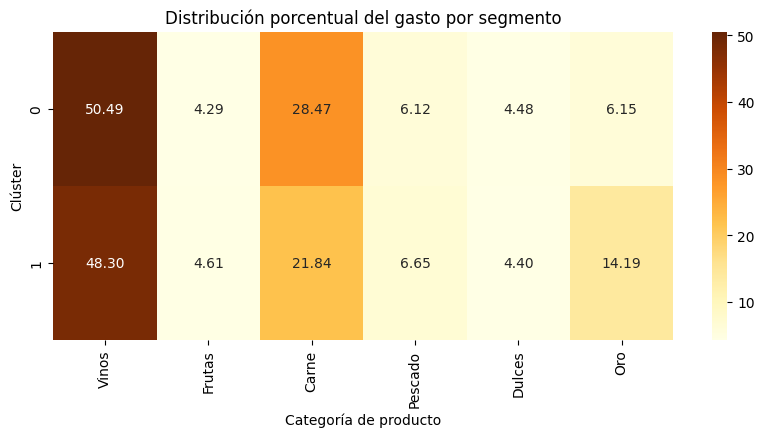

In [105]:
#Heatmap del gasto por producto y grupo
plt.figure(figsize=(10, 4))

ax = sns.heatmap(
    proporcion_gasto,
    annot=True,
    fmt='.2f',
    cmap='YlOrBr'
)

plt.title('Distribución porcentual del gasto por segmento')
plt.xlabel('Categoría de producto')
plt.ylabel('Clúster')

#Etiquetas
nuevas_etiquetas = {
    'MntWines': 'Vinos',
    'MntFruits': 'Frutas',
    'MntMeatProducts': 'Carne',
    'MntFishProducts': 'Pescado',
    'MntSweetProducts': 'Dulces',
    'MntGoldProds': 'Oro'
}
xticks_labels = [nuevas_etiquetas.get(label.get_text(), label.get_text()) for label in ax.get_xticklabels()]
ax.set_xticklabels(xticks_labels)

### Medios de compra

In [106]:
#Promedios y medianas de los medios de compra
canales = [
    'NumWebPurchases',
    'NumCatalogPurchases',
    'NumStorePurchases'
]

compras_canal = (data.groupby('Cluster_KMeans')[canales].agg(['mean', 'median']).round(2))
compras_canal.T

Cluster_KMeans                 0     1
NumWebPurchases     mean    5.84  2.69
                    median  6.00  2.00
NumCatalogPurchases mean    5.04  0.76
                    median  5.00  1.00
NumStorePurchases   mean    8.43  3.68
                    median  8.00  3.00

In [107]:
#Porcentaje de gasto por porducto de cada grupo
#Gasto total
canales_suma = (data.groupby('Cluster_KMeans')[canales].sum())

#Porcentajes
proporcion_canales = (canales_suma.div(canales_suma.sum(axis = 1), axis = 0) * 100).round(2)
proporcion_canales

,NumWebPurchases,NumCatalogPurchases,NumStorePurchases
Cluster_KMeans,,,
0,30.22,26.09,43.68
1,37.69,10.69,51.62


[Text(0.5, 0, 'Sitio Web'), Text(1.5, 0, 'Catálogo'), Text(2.5, 0, 'Tienda')]

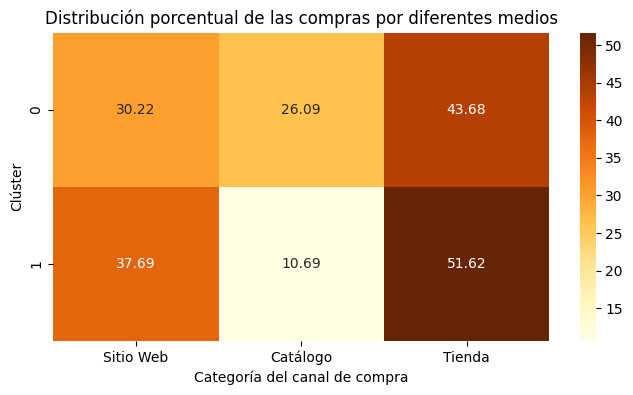

In [108]:
#Heatmap de las compras por diferentes medios
plt.figure(figsize=(8, 4))

ax = sns.heatmap(
    proporcion_canales,
    annot=True,
    fmt='.2f',
    cmap='YlOrBr'
)

plt.title('Distribución porcentual de las compras por diferentes medios')
plt.xlabel('Categoría del canal de compra')
plt.ylabel('Clúster')

#Etiquetas
nuevas_etiquetas = {
    'NumWebPurchases': 'Sitio Web',
    'NumCatalogPurchases': 'Catálogo',
    'NumStorePurchases': 'Tienda'
}
xticks_labels = [nuevas_etiquetas.get(label.get_text(), label.get_text()) for label in ax.get_xticklabels()]
ax.set_xticklabels(xticks_labels)

## Exportando modelo

In [109]:
#Datos
data.to_csv(
    'Datos Procesados - Segmentación de Clientes.csv',
    index = False
)

In [110]:
#Modelo
import joblib

joblib.dump(
    preprocessor,
    'Preprocesamiento_Segmentacion_Clientes.pkl'
)

joblib.dump(
    kmeans,
    'Modelo_Segmentacion_Clientes.pkl'
)

['Modelo_Segmentacion_Clientes.pkl']